# GARCH vs. Stochastic Volatility: S&P 500 and US Treasury Returns, 1990-2026

The previous notebook in this series (VARIMA and SVAR) modeled the *mean* dynamics of S&P 500 and Treasury returns but assumed constant shock variance throughout, a simplification real markets don't share: volatility clusters, large moves follow large moves. This notebook extends the same 1990-2026 dataset with genuine time-varying volatility and compares the two classic frameworks for modeling it:

- **GARCH** describes volatility as a *deterministic* function of past squared shocks and past volatility, no separate source of randomness in the volatility equation itself.
- **Stochastic Volatility (SV)** treats log-volatility as its *own* latent random process, driven by a second, independent noise term, making it a genuine state-space model. Estimating it reuses exactly the Kalman filter machinery from an earlier notebook in this series.

**What this notebook covers:**
1. Introducing the data: the same return system, now with realistic volatility clustering built in
2. GARCH(1,1): concept and maximum-likelihood estimation
3. Stochastic Volatility: concept and Kalman-filter quasi-likelihood estimation
4. Fitting both models to several series, including deliberate "wrong model" cases
5. Rolling one-week-ahead out-of-sample volatility forecasting

## 1. Introducing the Data

The same three-variable system as the previous notebook (T10Y_ret, T2Y_ret, SP500_ret, 1990-2026, same mean-equation VAR(2) dynamics and contemporaneous structure), extended with a genuine, known volatility process for each series:

- **SP500**: a true **GARCH(1,1)** process, $\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$, calibrated to realistic equity persistence ($\alpha=0.08$, $\beta=0.90$).
- **T10Y**: a true **stochastic volatility** process, $\log\sigma_t^2 = \mu + \phi(\log\sigma_{t-1}^2 - \mu) + \eta_t$, with its own separate noise $\eta_t$.
- **T2Y**: constant volatility, a control case with no true clustering at all, useful for checking neither model produces false positives.

Because SP500's observed shock is a mix of its own GARCH-driven innovation and a contemporaneous spillover from the (SV-driven) T10Y shock, its observed clustering is realistically a blend, dominated by its own GARCH process, but not perfectly pure. This is left in deliberately: real markets have exactly this kind of volatility spillover between asset classes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (7, 4.2), 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'grid.alpha': 0.35,
})

rng = np.random.default_rng(31)

n_years = 36
n_days = n_years * 252
dates = pd.bdate_range('1990-01-02', periods=n_days)
names = ['T10Y_ret', 'T2Y_ret', 'SP500_ret']
k = 3

A1 = np.array([[0.03, 0.05, 0.00], [0.02, 0.10, 0.00], [-0.15, 0.05, 0.02]])
A2 = np.array([[0.02, 0.00, 0.00], [0.00, 0.03, 0.00], [-0.06, 0.00, -0.02]])
c = np.array([0.010, 0.006, 0.038])
B0_inv = np.array([[1.00, 0.00, 0.00], [0.55, 1.00, 0.00], [-1.8, 0.35, 1.00]])

# T10Y: true stochastic volatility
sv_mu, sv_phi, sv_sigma_eta = np.log(0.28 ** 2), 0.97, 0.15
h_t10y = np.zeros(n_days); h_t10y[0] = sv_mu
for t in range(1, n_days):
    h_t10y[t] = sv_mu + sv_phi * (h_t10y[t-1] - sv_mu) + rng.normal(0, sv_sigma_eta)
sigma_t10y_true = np.exp(h_t10y / 2)

# T2Y: constant volatility (control case)
sigma_t2y_true = np.full(n_days, 0.16)

# SP500: true GARCH(1,1)
g_omega = 0.85 ** 2 * (1 - 0.08 - 0.90)
g_alpha, g_beta = 0.08, 0.90
sigma2_sp500_true = np.zeros(n_days); sigma2_sp500_true[0] = 0.85 ** 2
z_sp500 = rng.normal(0, 1, n_days)
eps_sp500 = np.zeros(n_days); eps_sp500[0] = np.sqrt(sigma2_sp500_true[0]) * z_sp500[0]
for t in range(1, n_days):
    sigma2_sp500_true[t] = g_omega + g_alpha * eps_sp500[t-1] ** 2 + g_beta * sigma2_sp500_true[t-1]
    eps_sp500[t] = np.sqrt(sigma2_sp500_true[t]) * z_sp500[t]
sigma_sp500_true = np.sqrt(sigma2_sp500_true)

eps_t10y = sigma_t10y_true * rng.normal(0, 1, n_days)
eps_t2y = sigma_t2y_true * rng.normal(0, 1, n_days)
eps = np.column_stack([eps_t10y, eps_t2y, eps_sp500])
u = eps @ B0_inv.T

Y = np.zeros((n_days, k))
Y[0], Y[1] = c, c
for t in range(2, n_days):
    Y[t] = c + A1 @ Y[t-1] + A2 @ Y[t-2] + u[t]

df = pd.DataFrame(Y, index=dates, columns=names)
print(f"Simulated {n_days} trading days, {k} variables")
print(f"Annualized volatility (%): {(df.std() * np.sqrt(252)).round(2).to_dict()}")

Simulated 9072 trading days, 3 variables
Annualized volatility (%): {'T10Y_ret': 4.91, 'T2Y_ret': 3.74, 'SP500_ret': 16.15}


**Diagram - volatility clustering.** The autocorrelation of squared returns is the standard diagnostic for ARCH effects: SP500 and T10Y both show clear positive autocorrelation (clustering), T2Y does not.

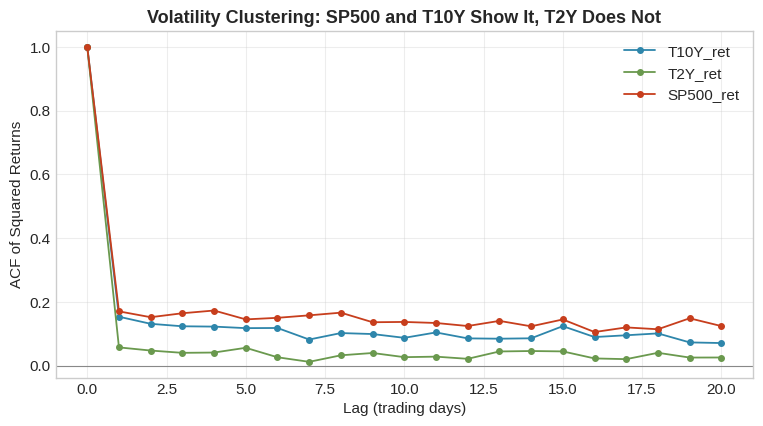

In [2]:
def acf_squared(series, max_lag=20):
    sq = (series - series.mean()) ** 2
    return [np.corrcoef(sq[lag:], sq[:-lag].values if lag > 0 else sq.values)[0, 1] if lag > 0 else 1.0
            for lag in range(max_lag + 1)]

fig, ax = plt.subplots(figsize=(9, 4.5))
colors3 = {'T10Y_ret': '#2E86AB', 'T2Y_ret': '#6A994E', 'SP500_ret': '#C73E1D'}
lags = range(21)
for col in names:
    acf_vals = acf_squared(df[col], max_lag=20)
    ax.plot(lags, acf_vals, 'o-', color=colors3[col], markersize=4, linewidth=1.3, label=col)
ax.axhline(0, color='#888888', linewidth=0.8)
ax.set_xlabel('Lag (trading days)'); ax.set_ylabel('ACF of Squared Returns')
ax.set_title('Volatility Clustering: SP500 and T10Y Show It, T2Y Does Not')
ax.legend()
plt.show()

## 2. GARCH(1,1): Concept and Estimation

GARCH (Generalized Autoregressive Conditional Heteroskedasticity) models the conditional variance as a **deterministic** function of the past:

$$\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2, \qquad \varepsilon_t = \sigma_t z_t,\ z_t \sim \mathcal{N}(0,1)$$

Given $\omega$, $\alpha$, $\beta$ and the history of returns, $\sigma_t^2$ is known *exactly*, no separate randomness enters the volatility equation itself; all the uncertainty is in $z_t$. $\alpha$ captures how strongly a large shock raises next period's variance ("ARCH effect"); $\beta$ captures how persistent volatility is; $\alpha+\beta$ close to 1 means shocks to volatility decay slowly (highly persistent clustering), a well-documented feature of real equity markets.

**Estimation** is by maximum likelihood: given the recursive $\sigma_t^2$, the (Gaussian) log-likelihood is $-\tfrac12\sum_t\left(\log(2\pi\sigma_t^2) + \varepsilon_t^2/\sigma_t^2\right)$, maximized numerically over $(\omega,\alpha,\beta)$.

In [3]:
def garch_negloglik(params, r):
    omega, alpha, beta = params
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 0.999:
        return 1e10
    n = len(r)
    sigma2 = np.empty(n)
    sigma2[0] = np.var(r)
    r2 = r ** 2
    total = 0.0
    for t in range(1, n):
        sigma2[t] = omega + alpha * r2[t-1] + beta * sigma2[t-1]
        total += np.log(sigma2[t]) + r2[t] / sigma2[t]
    return total   # (proportional to -2*loglik, up to a constant; fine for minimization)

def fit_garch(r):
    r_dm = (r - r.mean()).values
    uncond_var = np.var(r_dm)
    x0 = [uncond_var * 0.05, 0.05, 0.90]
    bounds = [(1e-8, uncond_var * 3), (1e-4, 0.4), (0.3, 0.999)]
    res = minimize(garch_negloglik, x0, args=(r_dm,), method='L-BFGS-B', bounds=bounds,
                    options={'maxiter': 300, 'ftol': 1e-10})
    omega, alpha, beta = res.x
    return dict(omega=omega, alpha=alpha, beta=beta, obj=res.fun, success=res.success)

def garch_filtered_vol(r, omega, alpha, beta):
    r_dm = (r - r.mean()).values
    n = len(r_dm)
    sigma2 = np.empty(n); sigma2[0] = np.var(r_dm)
    r2 = r_dm ** 2
    for t in range(1, n):
        sigma2[t] = omega + alpha * r2[t-1] + beta * sigma2[t-1]
    return np.sqrt(sigma2)

garch_fits = {}
for col in names:
    fit = fit_garch(df[col])
    garch_fits[col] = fit
    print(f"{col:<12} GARCH(1,1): omega={fit['omega']:.5f}  alpha={fit['alpha']:.4f}  "
          f"beta={fit['beta']:.4f}  persistence(a+b)={fit['alpha']+fit['beta']:.4f}")

print(f"\nTrue SP500 GARCH: omega={g_omega:.5f}  alpha=0.08  beta=0.90")

T10Y_ret     GARCH(1,1): omega=0.00228  alpha=0.0834  beta=0.8941  persistence(a+b)=0.9775
T2Y_ret      GARCH(1,1): omega=0.00140  alpha=0.0295  beta=0.9453  persistence(a+b)=0.9748
SP500_ret    GARCH(1,1): omega=0.02381  alpha=0.0591  beta=0.9170  persistence(a+b)=0.9761

True SP500 GARCH: omega=0.01445  alpha=0.08  beta=0.90


## 3. Stochastic Volatility: Concept and Estimation

Stochastic Volatility treats log-variance as a **latent state with its own noise**, a genuine hidden Markov / state-space model rather than a deterministic recursion:

$$\log \sigma_t^2 = \mu + \phi\,(\log \sigma_{t-1}^2 - \mu) + \eta_t, \qquad \eta_t \sim \mathcal{N}(0, \sigma_\eta^2)$$
$$\varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1)$$

Even knowing every past return exactly, $\sigma_t^2$ is *not* known with certainty, $\eta_t$ is an independent source of randomness that can push volatility around beyond what past shocks alone would predict. This makes SV strictly more flexible than GARCH, but harder to estimate: the likelihood requires integrating out the unobserved path of $h_t = \log\sigma_t^2$.

**Estimation** uses the classic Harvey-Ruiz-Shephard (1994) linearization, and reuses the Kalman filter directly from the earlier notebook in this series. Squaring and log-transforming the (demeaned) returns gives:

$$x_t \equiv \log \varepsilon_t^2 = \mu + h_t + \xi_t, \qquad \xi_t \equiv \log z_t^2$$

$\xi_t$ has a known, fixed distribution (log of a chi-squared with 1 degree of freedom): mean $-1.2704$, variance $\pi^2/2$. Approximating it as Gaussian turns the whole system into an exact **linear-Gaussian state-space model**, exactly the form the Kalman filter is built for, with $h_t$ as the hidden state.

In [4]:
XI_MEAN, XI_VAR = -1.2704, (np.pi ** 2) / 2

def kalman_loglik_sv(params, x):
    mu, phi, log_sigma_eta = params
    sigma_eta2 = np.exp(log_sigma_eta) ** 2
    n = len(x)
    h_pred, P_pred = 0.0, sigma_eta2 / max(1 - phi ** 2, 1e-4)
    ll = 0.0
    for t in range(n):
        S = P_pred + XI_VAR
        innovation = x[t] - (mu + h_pred)
        ll += -0.5 * (np.log(2 * np.pi * S) + innovation ** 2 / S)
        K = P_pred / S
        h_upd = h_pred + K * innovation
        P_upd = P_pred - K * P_pred
        h_pred = phi * h_upd
        P_pred = phi ** 2 * P_upd + sigma_eta2
    return -ll

def fit_sv(r):
    r_dm = r - r.mean()
    x = np.log(r_dm.values ** 2 + 1e-8)
    x0 = [x.mean() - XI_MEAN, 0.9, np.log(0.2)]
    res = minimize(kalman_loglik_sv, x0, args=(x,), method='Nelder-Mead',
                    options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 2000})
    mu, phi, log_sigma_eta = res.x
    sigma_eta = np.exp(log_sigma_eta)
    # Standard QML bias correction: the Gaussian approximation of xi_t biases the level (mu);
    # re-match mu to the sample second moment, keeping the MLE's phi and sigma_eta.
    stat_var_h = sigma_eta ** 2 / (1 - phi ** 2)
    mu_corrected = np.log(np.mean(r_dm.values ** 2)) - stat_var_h / 2
    return dict(mu=mu_corrected, mu_raw=mu, phi=phi, sigma_eta=sigma_eta, loglik=-res.fun, success=res.success)

def sv_filtered_vol(r, mu, phi, sigma_eta):
    r_dm = r - r.mean()
    x = np.log(r_dm.values ** 2 + 1e-8)
    n = len(x)
    sigma_eta2 = sigma_eta ** 2
    h_pred, P_pred = 0.0, sigma_eta2 / max(1 - phi ** 2, 1e-4)
    h_filtered = np.empty(n)
    for t in range(n):
        S = P_pred + XI_VAR
        innovation = x[t] - (mu + h_pred)
        K = P_pred / S
        h_upd = h_pred + K * innovation
        P_upd = P_pred - K * P_pred
        h_filtered[t] = h_upd
        h_pred = phi * h_upd
        P_pred = phi ** 2 * P_upd + sigma_eta2
    return np.exp((mu + h_filtered) / 2)

sv_fits = {}
for col in names:
    fit = fit_sv(df[col])
    sv_fits[col] = fit
    print(f"{col:<12} SV: mu={fit['mu']:.4f}  phi={fit['phi']:.4f}  sigma_eta={fit['sigma_eta']:.4f}  "
          f"implied vol={np.exp(fit['mu']/2):.3f}%")

print(f"\nTrue T10Y SV: mu={sv_mu:.4f}  phi=0.97  sigma_eta=0.15  implied vol=0.280%")

T10Y_ret     SV: mu=-2.5667  phi=0.9738  sigma_eta=0.1512  implied vol=0.277%
T2Y_ret      SV: mu=-2.9295  phi=0.9771  sigma_eta=0.0600  implied vol=0.231%
SP500_ret    SV: mu=-0.1150  phi=0.9809  sigma_eta=0.1065  implied vol=0.944%

True T10Y SV: mu=-2.5459  phi=0.97  sigma_eta=0.15  implied vol=0.280%


## 4. Fitting Both Models to Several Series: Right Model, Wrong Model

Both GARCH and SV are now fit to all three series, giving 6 total cases: each model on its own "home turf" (GARCH on SP500, SV on T10Y), each model on the *other's* home turf (GARCH on T10Y, SV on SP500), and both on the no-clustering control (T2Y). The filtered volatility path, the model's own best real-time estimate of $\sigma_t$ given data up to time $t$, is compared to the true simulated volatility for the two interesting cases.

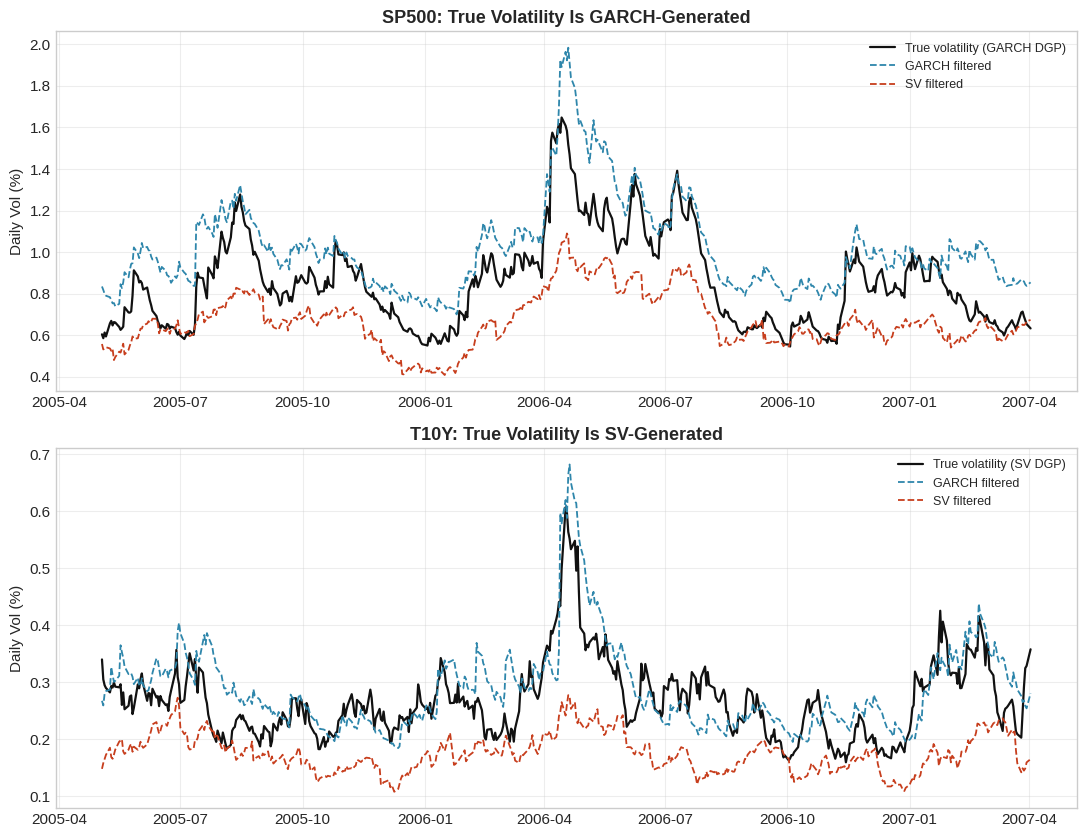

In [5]:
garch_vol_sp500 = garch_filtered_vol(df['SP500_ret'], **{k: garch_fits['SP500_ret'][k] for k in ['omega','alpha','beta']})
sv_vol_sp500 = sv_filtered_vol(df['SP500_ret'], sv_fits['SP500_ret']['mu'], sv_fits['SP500_ret']['phi'], sv_fits['SP500_ret']['sigma_eta'])
garch_vol_t10y = garch_filtered_vol(df['T10Y_ret'], **{k: garch_fits['T10Y_ret'][k] for k in ['omega','alpha','beta']})
sv_vol_t10y = sv_filtered_vol(df['T10Y_ret'], sv_fits['T10Y_ret']['mu'], sv_fits['T10Y_ret']['phi'], sv_fits['T10Y_ret']['sigma_eta'])

window = slice(4000, 4500)   # a representative 500-day window for visual clarity
fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))

ax = axes[0]
ax.plot(df.index[window], sigma_sp500_true[window], color='#111111', linewidth=1.6, label='True volatility (GARCH DGP)')
ax.plot(df.index[window], garch_vol_sp500[window], color='#2E86AB', linewidth=1.3, linestyle='--', label='GARCH filtered')
ax.plot(df.index[window], sv_vol_sp500[window], color='#C73E1D', linewidth=1.3, linestyle='--', label='SV filtered')
ax.set_title('SP500: True Volatility Is GARCH-Generated'); ax.set_ylabel('Daily Vol (%)'); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(df.index[window], sigma_t10y_true[window], color='#111111', linewidth=1.6, label='True volatility (SV DGP)')
ax.plot(df.index[window], garch_vol_t10y[window], color='#2E86AB', linewidth=1.3, linestyle='--', label='GARCH filtered')
ax.plot(df.index[window], sv_vol_t10y[window], color='#C73E1D', linewidth=1.3, linestyle='--', label='SV filtered')
ax.set_title('T10Y: True Volatility Is SV-Generated'); ax.set_ylabel('Daily Vol (%)'); ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Fit quality summary**, measured two ways: RMSE of each model's filtered volatility against the true simulated path (only possible here because the ground truth is known), and a fair, apples-to-apples **return log-likelihood** (plugging each model's own filtered $\sigma_t$ back into the standard Gaussian return density, directly comparable across model classes regardless of how the volatility path was estimated).

In [6]:
def return_loglik(r, sigma):
    r_dm = (r - r.mean()).values
    return np.sum(-0.5 * (np.log(2 * np.pi * sigma ** 2) + r_dm ** 2 / sigma ** 2))

ll_garch_sp500 = return_loglik(df['SP500_ret'], garch_vol_sp500)
ll_sv_sp500 = return_loglik(df['SP500_ret'], sv_vol_sp500)
ll_garch_t10y = return_loglik(df['T10Y_ret'], garch_vol_t10y)
ll_sv_t10y = return_loglik(df['T10Y_ret'], sv_vol_t10y)

rmse_table = pd.DataFrame({
    'GARCH RMSE vs. true': [np.sqrt(np.mean((garch_vol_sp500 - sigma_sp500_true) ** 2)),
                            np.sqrt(np.mean((garch_vol_t10y - sigma_t10y_true) ** 2))],
    'SV RMSE vs. true': [np.sqrt(np.mean((sv_vol_sp500 - sigma_sp500_true) ** 2)),
                         np.sqrt(np.mean((sv_vol_t10y - sigma_t10y_true) ** 2))],
    'GARCH return-loglik': [ll_garch_sp500, ll_garch_t10y],
    'SV return-loglik': [ll_sv_sp500, ll_sv_t10y],
}, index=['SP500 (true DGP: GARCH)', 'T10Y (true DGP: SV)'])
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', None)
print(rmse_table.round(2))

                         GARCH RMSE vs. true  SV RMSE vs. true  GARCH return-loglik  SV return-loglik
SP500 (true DGP: GARCH)                 0.21              0.23            -12585.44         -14199.40
T10Y (true DGP: SV)                     0.06              0.12             -1739.65          -3474.27


**GARCH wins on both series, even on T10Y where SV is the true model.** This is not evidence that GARCH is secretly the better model class, it is a well-documented property of the *estimation method* used here. The Kalman-QML approach only feeds the filter $\log \varepsilon_t^2$, using a crude Gaussian approximation to a genuinely skewed distribution, a much noisier signal than GARCH's direct, exact use of $\varepsilon_{t-1}^2$ in its recursion. Real-time (filtered) SV estimates from this method are known to be noisier than GARCH's, even when SV is correctly specified. More accurate SV estimation (MCMC-based mixture approximations, or particle filters, standard in the specialist literature) closes this gap, at real additional computational cost, exactly the kind of MCMC machinery built in an earlier notebook in this series.

## 5. Rolling One-Week-Ahead Out-of-Sample Volatility Forecast

The same walk-forward discipline as the previous notebook, now applied to **volatility** rather than returns: at each origin in the final two years of data, both models forecast **realized volatility over the next 5 trading days**, $\sqrt{\tfrac15\sum_{i=1}^5 E[\varepsilon_{t+i}^2\mid \text{info}_t]}$, using only information available up to that day. Parameters are refit periodically (every 125 trading days, about twice a year, the realistic cadence at which volatility models are typically re-estimated in practice) rather than daily, since GARCH and SV estimation both require numerical optimization, unlike the previous notebook's closed-form VAR refits.

- **GARCH forecast**: iterate the variance recursion forward, $E[\sigma_{t+1}^2] = \omega + \alpha\varepsilon_t^2 + \beta\sigma_t^2$, then $E[\sigma_{t+h}^2] = \omega + (\alpha+\beta)E[\sigma_{t+h-1}^2]$ for $h \ge 2$.
- **SV forecast**: the AR(1) state mean-reverts geometrically, $E[h_{t+h}] = \phi^h h_t$, with forecast variance $\text{Var}[h_{t+h}] = \sigma_\eta^2(1-\phi^{2h})/(1-\phi^2)$; the log-normal moment formula converts this back to an expected variance.

In [7]:
def garch_forecast_realized_vol(sigma2_t, eps2_t, omega, alpha, beta, h=5):
    fc = [omega + alpha * eps2_t + beta * sigma2_t]
    for _ in range(2, h + 1):
        fc.append(omega + (alpha + beta) * fc[-1])
    return np.sqrt(np.mean(fc))

def sv_forecast_realized_vol(h_t, mu, phi, sigma_eta, h=5):
    fc = []
    for horizon in range(1, h + 1):
        mean_h = phi ** horizon * h_t
        var_h = sigma_eta ** 2 * (1 - phi ** (2 * horizon)) / (1 - phi ** 2)
        fc.append(np.exp(mu + mean_h + var_h / 2))
    return np.sqrt(np.mean(fc))

def run_rolling_vol_forecast(r, n_test, h, refit_every):
    n_total = len(r)
    start_idx = n_total - n_test - h
    r_dm_full = (r - r.mean()).values

    forecasts_garch, forecasts_sv, actual_rv = np.zeros(n_test), np.zeros(n_test), np.zeros(n_test)
    garch_params = sv_params = sigma2_state = h_state = None

    for j in range(n_test):
        origin = start_idx + j
        if j % refit_every == 0:
            r_train = r.iloc[:origin]
            garch_params, sv_params = fit_garch(r_train), fit_sv(r_train)

            n_tr = origin
            sigma2_path = np.empty(n_tr); sigma2_path[0] = np.var(r_dm_full[:n_tr])
            for t in range(1, n_tr):
                sigma2_path[t] = garch_params['omega'] + garch_params['alpha']*r_dm_full[t-1]**2 + garch_params['beta']*sigma2_path[t-1]
            sigma2_state = sigma2_path[-1]

            sigma_eta2 = sv_params['sigma_eta'] ** 2
            P_ss = sigma_eta2 / max(1 - sv_params['phi'] ** 2, 1e-4)
            h_pred, P_pred = 0.0, P_ss
            for t in range(n_tr):
                x_t = np.log(r_dm_full[t] ** 2 + 1e-8)
                S = P_pred + XI_VAR
                innov = x_t - (sv_params['mu'] + h_pred)
                K = P_pred / S
                h_upd = h_pred + K * innov
                h_pred = sv_params['phi'] * h_upd
                P_pred = sv_params['phi'] ** 2 * (P_pred - K * P_pred) + sigma_eta2
            h_state = h_upd
        else:
            t = origin - 1
            sigma2_state = garch_params['omega'] + garch_params['alpha']*r_dm_full[t]**2 + garch_params['beta']*sigma2_state
            P_ss = sv_params['sigma_eta']**2 / max(1 - sv_params['phi']**2, 1e-4)
            x_t = np.log(r_dm_full[t] ** 2 + 1e-8)
            S = P_ss + XI_VAR
            innov = x_t - (sv_params['mu'] + sv_params['phi'] * h_state)
            K = P_ss / S
            h_state = sv_params['phi'] * h_state + K * innov

        eps2_t = r_dm_full[origin - 1] ** 2
        forecasts_garch[j] = garch_forecast_realized_vol(sigma2_state, eps2_t, garch_params['omega'], garch_params['alpha'], garch_params['beta'], h)
        forecasts_sv[j] = sv_forecast_realized_vol(h_state, sv_params['mu'], sv_params['phi'], sv_params['sigma_eta'], h)
        actual_rv[j] = np.sqrt(np.mean(r_dm_full[origin: origin + h] ** 2))

    return forecasts_garch, forecasts_sv, actual_rv

h, n_test, refit_every = 5, 500, 125
fc_garch_sp500, fc_sv_sp500, actual_sp500 = run_rolling_vol_forecast(df['SP500_ret'], n_test, h, refit_every)
fc_garch_t10y, fc_sv_t10y, actual_t10y = run_rolling_vol_forecast(df['T10Y_ret'], n_test, h, refit_every)

print(f"Rolling forecast complete: {n_test} weekly origins per series, refit every {refit_every} days")

Rolling forecast complete: 500 weekly origins per series, refit every 125 days


**Diagram - forecast vs. realized volatility.** Both models' 1-week-ahead volatility forecasts against what was actually realized.

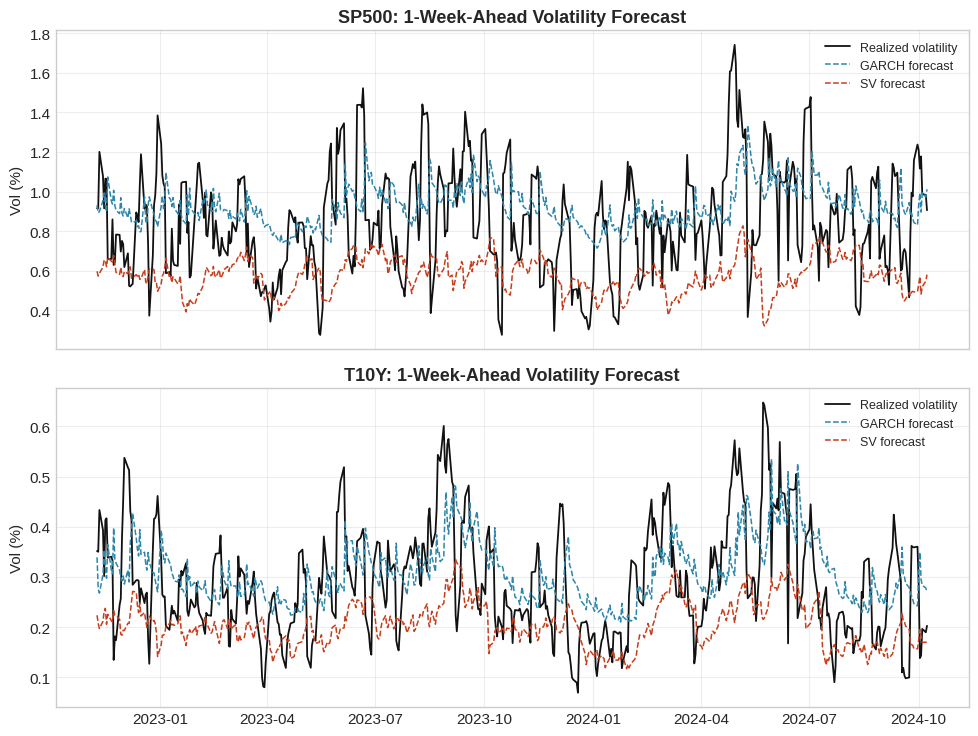

In [8]:
test_dates = df.index[len(df) - 500 - h + h - 1 : len(df) - h + h - 1][:n_test]

fig, axes = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True)
for ax, name_lbl, actual, fg, fs in [
    (axes[0], 'SP500', actual_sp500, fc_garch_sp500, fc_sv_sp500),
    (axes[1], 'T10Y', actual_t10y, fc_garch_t10y, fc_sv_t10y),
]:
    ax.plot(test_dates, actual, color='#111111', linewidth=1.3, label='Realized volatility')
    ax.plot(test_dates, fg, color='#2E86AB', linewidth=1.1, linestyle='--', label='GARCH forecast')
    ax.plot(test_dates, fs, color='#C73E1D', linewidth=1.1, linestyle='--', label='SV forecast')
    ax.set_title(f'{name_lbl}: 1-Week-Ahead Volatility Forecast')
    ax.set_ylabel('Vol (%)')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Error summary**, against a naive historical-average-volatility benchmark.

In [9]:
def rmse(a, b): return np.sqrt(np.mean((a - b) ** 2))

naive_sp500 = np.full(n_test, df['SP500_ret'].iloc[-750:-500].std())
naive_t10y = np.full(n_test, df['T10Y_ret'].iloc[-750:-500].std())

vol_summary = pd.DataFrame({
    'GARCH RMSE': [rmse(fc_garch_sp500, actual_sp500), rmse(fc_garch_t10y, actual_t10y)],
    'SV RMSE': [rmse(fc_sv_sp500, actual_sp500), rmse(fc_sv_t10y, actual_t10y)],
    'Naive (historical avg) RMSE': [rmse(naive_sp500, actual_sp500), rmse(naive_t10y, actual_t10y)],
    'Corr(GARCH, actual)': [np.corrcoef(fc_garch_sp500, actual_sp500)[0,1], np.corrcoef(fc_garch_t10y, actual_t10y)[0,1]],
    'Corr(SV, actual)': [np.corrcoef(fc_sv_sp500, actual_sp500)[0,1], np.corrcoef(fc_sv_t10y, actual_t10y)[0,1]],
}, index=['SP500', 'T10Y'])
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', None)
print(vol_summary.round(4))

       GARCH RMSE  SV RMSE  Naive (historical avg) RMSE  Corr(GARCH, actual)  Corr(SV, actual)
SP500      0.2840   0.3937                       0.2685               0.0951           -0.0262
T10Y       0.1064   0.1336                       0.1102               0.3512            0.3724
